In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.neighbors import KNeighborsClassifier

from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score
from sklearn import metrics


In [2]:
df=pd.read_csv("sdn_ai_dataset_10000.csv")
df.sample(10)


,timestamp,cpu_usage,ram_usage,disk_usage,network_in,network_out,disk_read,disk_write,temperature,process_count,anomaly
4019,04:59:01,43.1,58.4,52.3,171,87,36,23,53.1,144,0
8760,12:00:01,33.5,57.2,51.2,113,120,33,30,50.8,127,0
6119,15:59:01,54.0,56.1,54.0,164,109,39,24,46.6,117,0
8484,07:24:01,86.8,90.7,61.6,1420,668,439,575,82.2,528,1
2056,20:16:01,41.9,52.5,56.1,171,80,24,28,50.7,121,0
4327,10:07:01,47.2,54.4,58.9,131,92,30,18,53.8,131,0
839,23:59:01,31.8,53.8,53.0,179,135,33,21,47.1,124,0
1800,16:00:01,49.3,53.9,51.7,154,103,39,18,52.5,131,0
5739,09:39:01,55.9,51.8,58.4,121,99,21,23,46.8,122,0
2695,06:55:01,30.8,45.2,54.2,129,114,39,26,52.3,145,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   timestamp      10000 non-null  object 
 1   cpu_usage      10000 non-null  float64
 2   ram_usage      10000 non-null  float64
 3   disk_usage     10000 non-null  float64
 4   network_in     10000 non-null  int64  
 5   network_out    10000 non-null  int64  
 6   disk_read      10000 non-null  int64  
 7   disk_write     10000 non-null  int64  
 8   temperature    10000 non-null  float64
 9   process_count  10000 non-null  int64  
 10  anomaly        10000 non-null  int64  
dtypes: float64(4), int64(6), object(1)
memory usage: 859.5+ KB


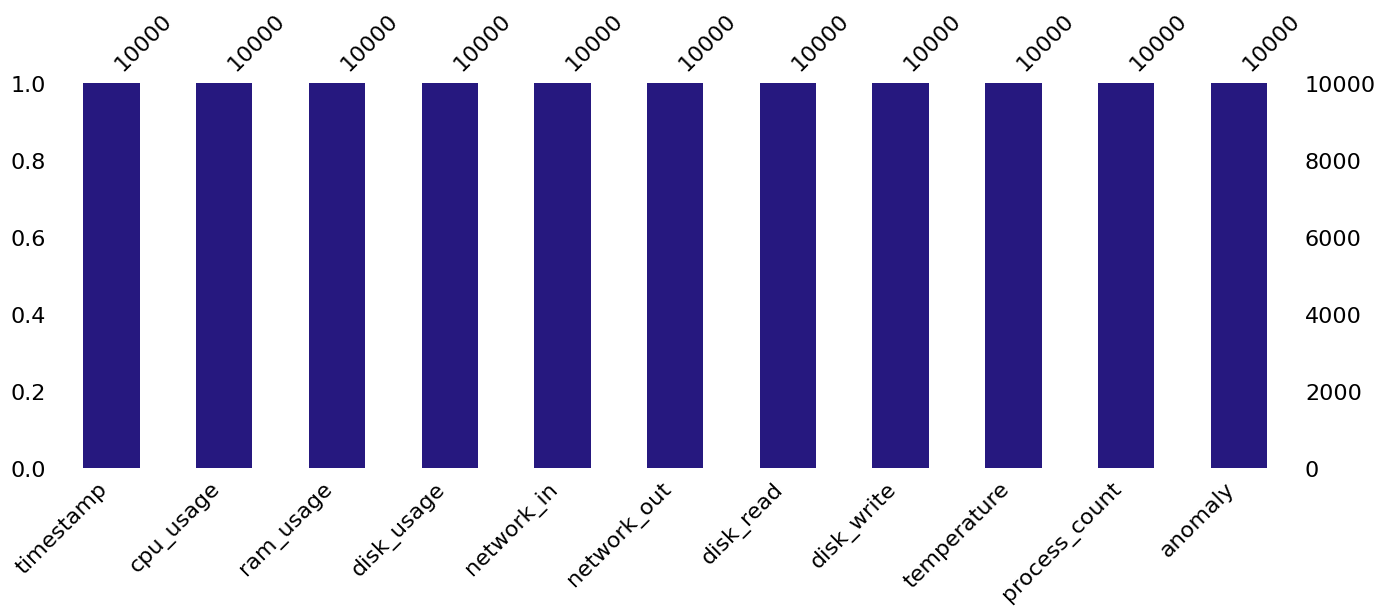

In [4]:
missing_values = msno.bar(df, figsize= (16,5),color="#26187f")

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
cpu_usage,10000.0,48.59332,15.082592,30.0,37.9,46.3,54.4,99.9
ram_usage,10000.0,55.46682,11.398045,45.0,49.0,53.0,57.1,100.0
disk_usage,10000.0,55.45470,3.511107,50.0,52.6,55.3,57.9,70.0
network_in,10000.0,212.77240,261.076341,100.0,122.0,144.0,166.0,1498.0
network_out,10000.0,182.68560,245.578216,80.0,99.0,117.0,138.0,1399.0
disk_read,10000.0,75.03750,163.603346,20.0,25.0,31.0,37.0,900.0
disk_write,10000.0,62.15170,144.603238,15.0,19.0,23.0,27.0,800.0
temperature,10000.0,51.27407,10.344885,42.0,45.5,49.1,52.6,95.0
process_count,10000.0,155.70690,92.870381,110.0,121.0,132.0,143.0,600.0
anomaly,10000.0,0.07530,0.263888,0.0,0.0,0.0,0.0,1.0


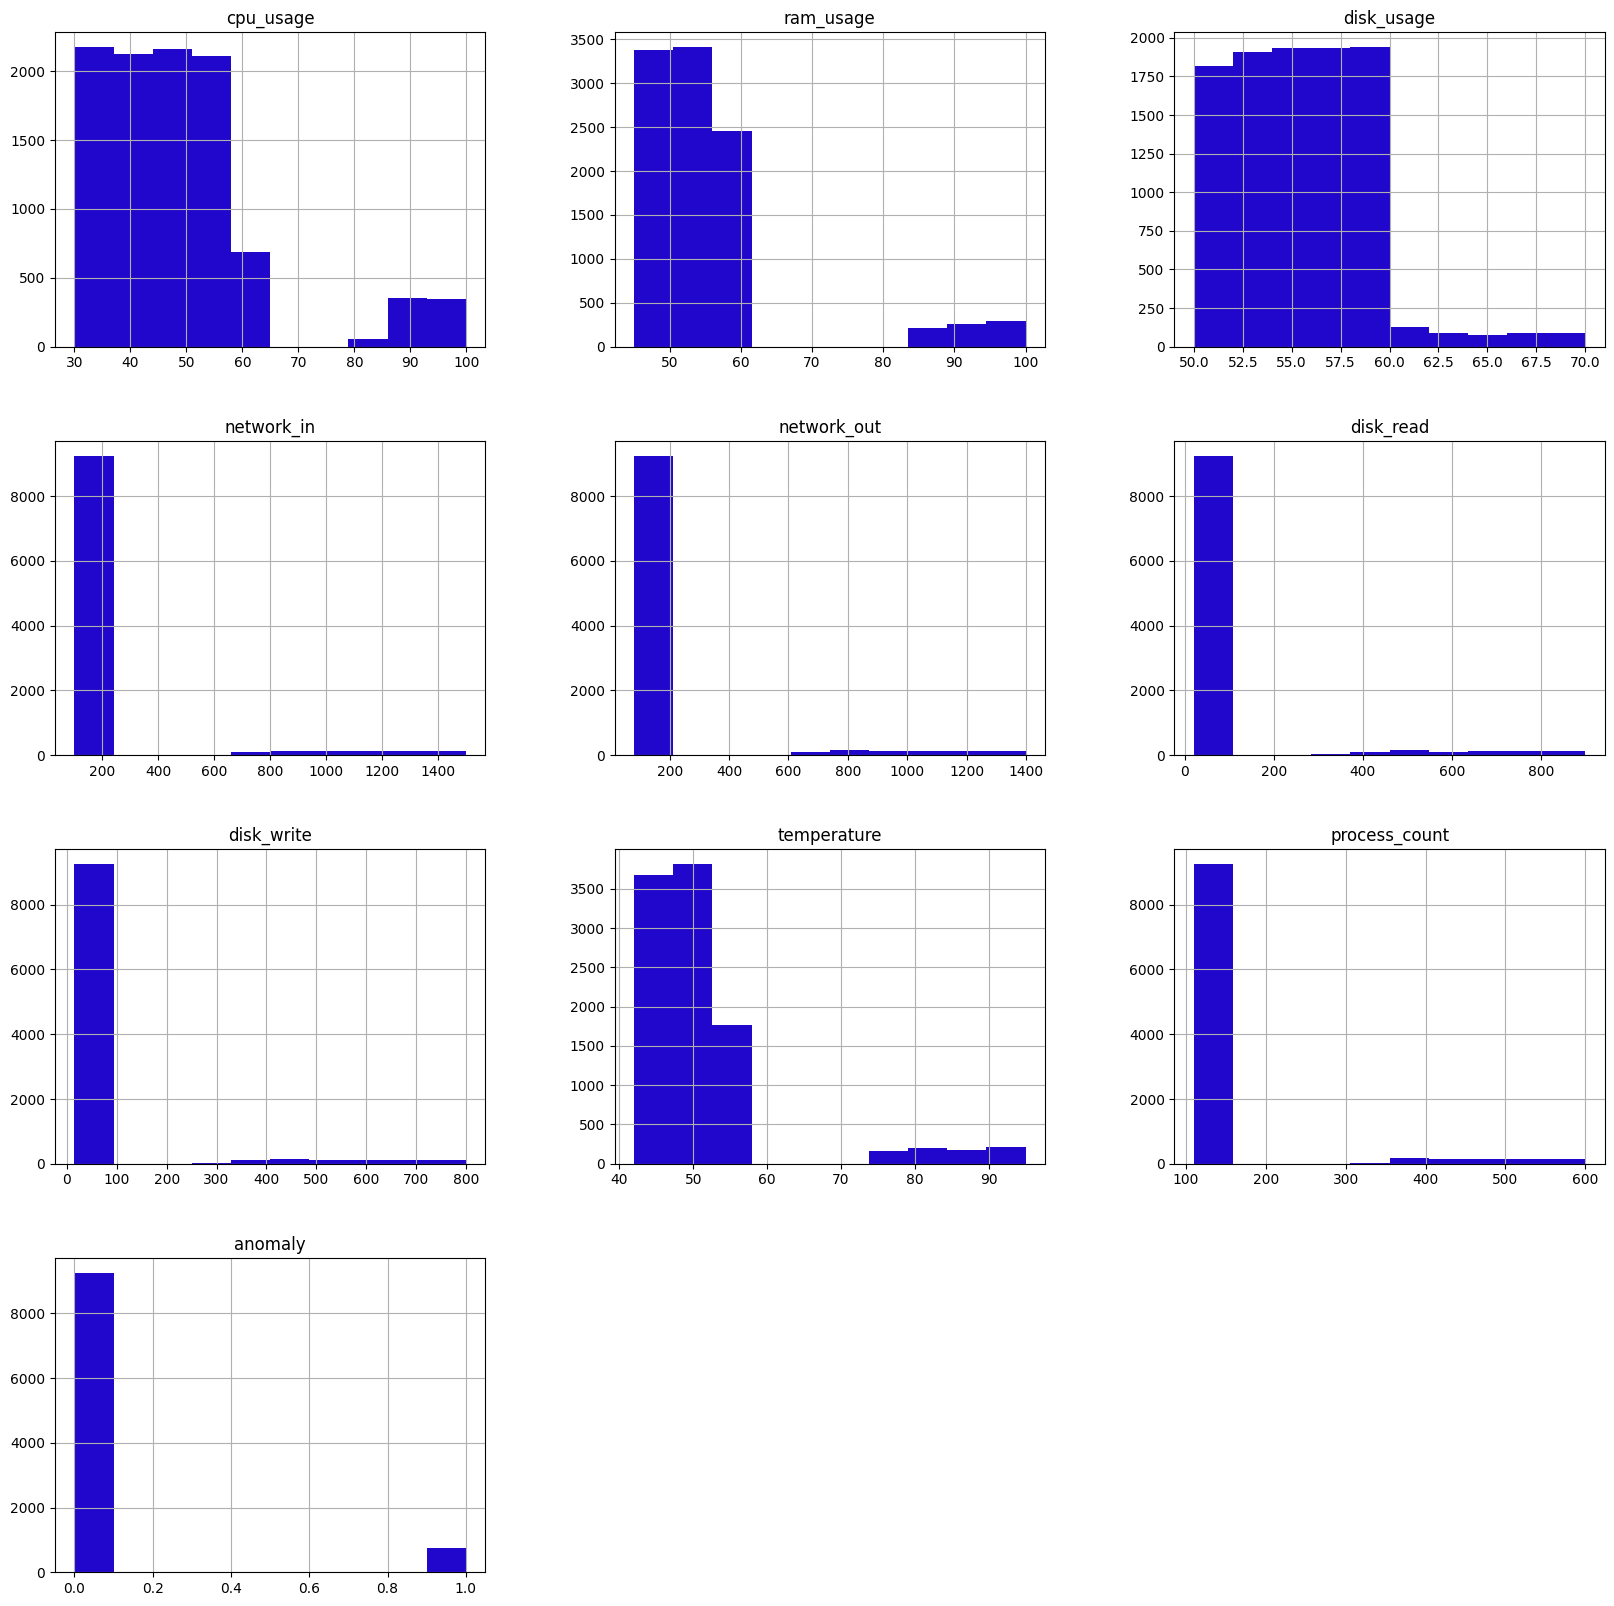

In [6]:
hist_plot = df.hist(figsize=(20,20), color = "#2107CC")

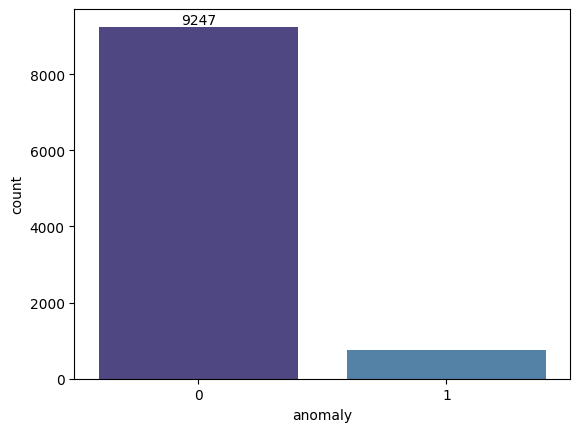

In [7]:
colors=["#483D8B","#4682B4","#87CEFA"]
ax= sns.countplot(data=df, x="anomaly" , palette=colors)
ax.bar_label(ax.containers[0])
plt.show()

In [8]:
df=df.drop(columns=['timestamp'])

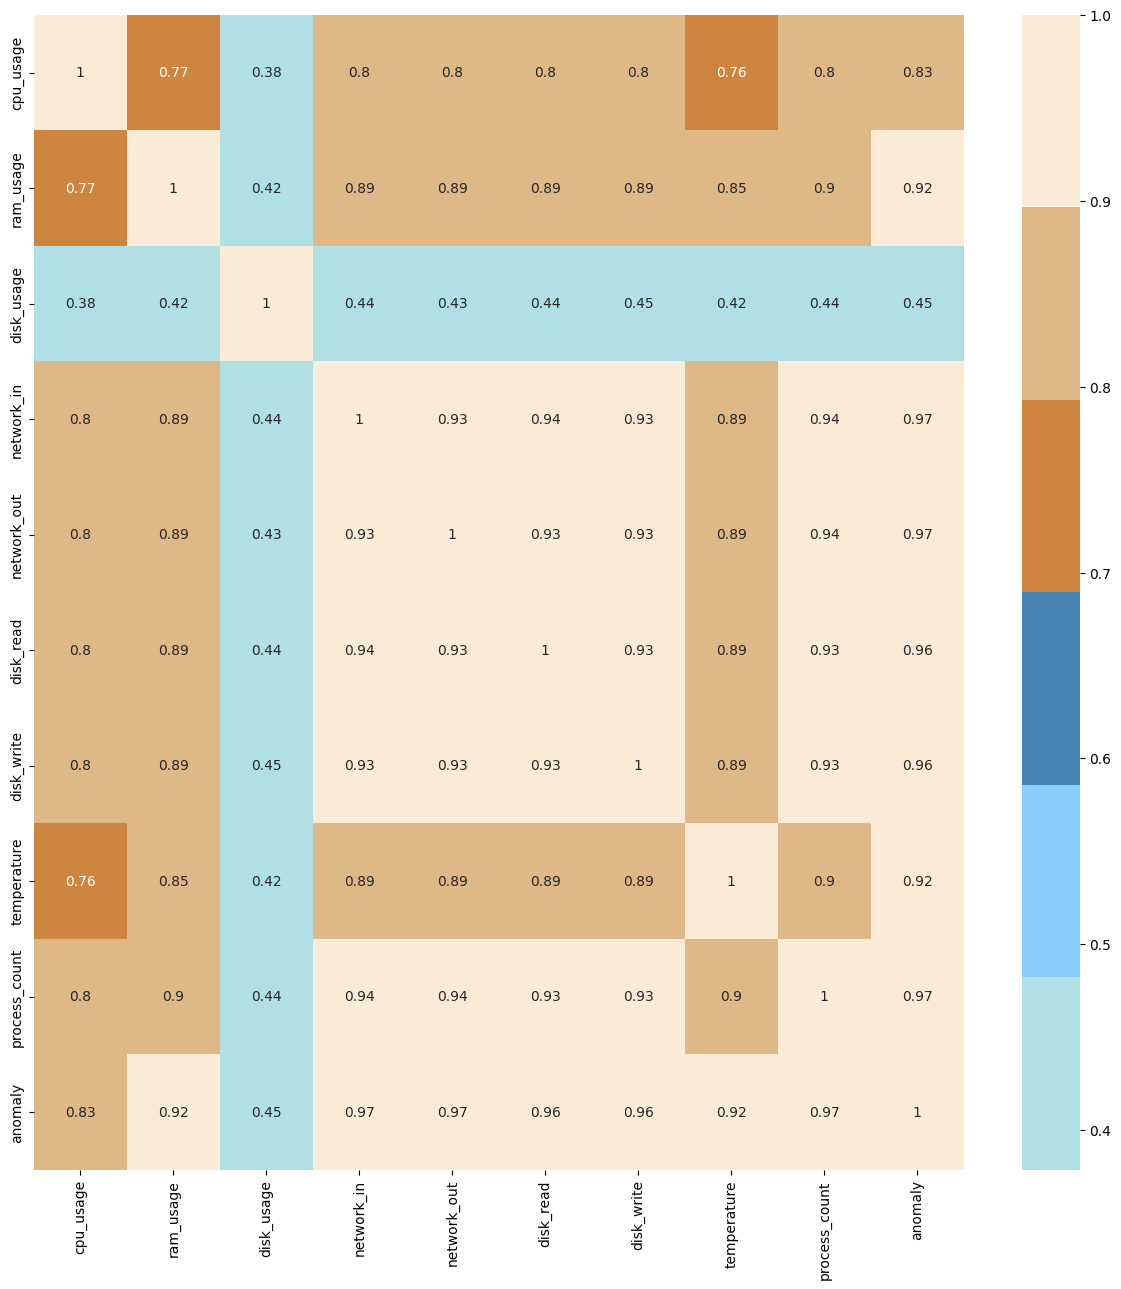

In [9]:
cmap=sns.diverging_palette(205, 133, 63, as_cmap=True)
cols=(["#B0E0E6", "#87CEFA", "#4682B4", "#CD853F", "#DEB887", "#FAEBD7"])
corrmat= df.corr()
f, ax=plt.subplots(figsize=(15,15))
sns.heatmap(corrmat,cmap=cols,annot=True)
plt.show()

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
X=df.drop(["anomaly"],axis=1)
y=df["anomaly"]

In [12]:
col_names=list(X.columns)
s_scaler=StandardScaler()
X_scaled=s_scaler.fit_transform(X)
X_scaled=pd.DataFrame(X_scaled, columns=col_names)
X_scaled.describe().T

,count,mean,std,min,25%,50%,75%,max
cpu_usage,10000.0,1.008971e-16,1.00005,-1.232829,-0.709020,-0.152058,0.385011,3.401885
ram_usage,10000.0,1.321609e-16,1.00005,-0.918345,-0.567391,-0.216436,0.143293,3.907285
disk_usage,10000.0,-7.318590e-16,1.00005,-1.553633,-0.813089,-0.044062,0.696482,4.142861
network_in,10000.0,-3.623768e-17,1.00005,-0.431973,-0.347703,-0.263432,-0.179161,4.923050
network_out,10000.0,1.563194e-17,1.00005,-0.418159,-0.340787,-0.267487,-0.181970,4.953107
disk_read,10000.0,2.273737e-17,1.00005,-0.336425,-0.305862,-0.269186,-0.232510,5.042707
disk_write,10000.0,8.171241e-18,1.00005,-0.326093,-0.298429,-0.270766,-0.243103,5.102826
temperature,10000.0,5.108802e-16,1.00005,-0.896533,-0.558185,-0.210169,0.128179,4.227028
process_count,10000.0,9.023893e-17,1.00005,-0.492183,-0.373732,-0.255281,-0.136831,4.784252


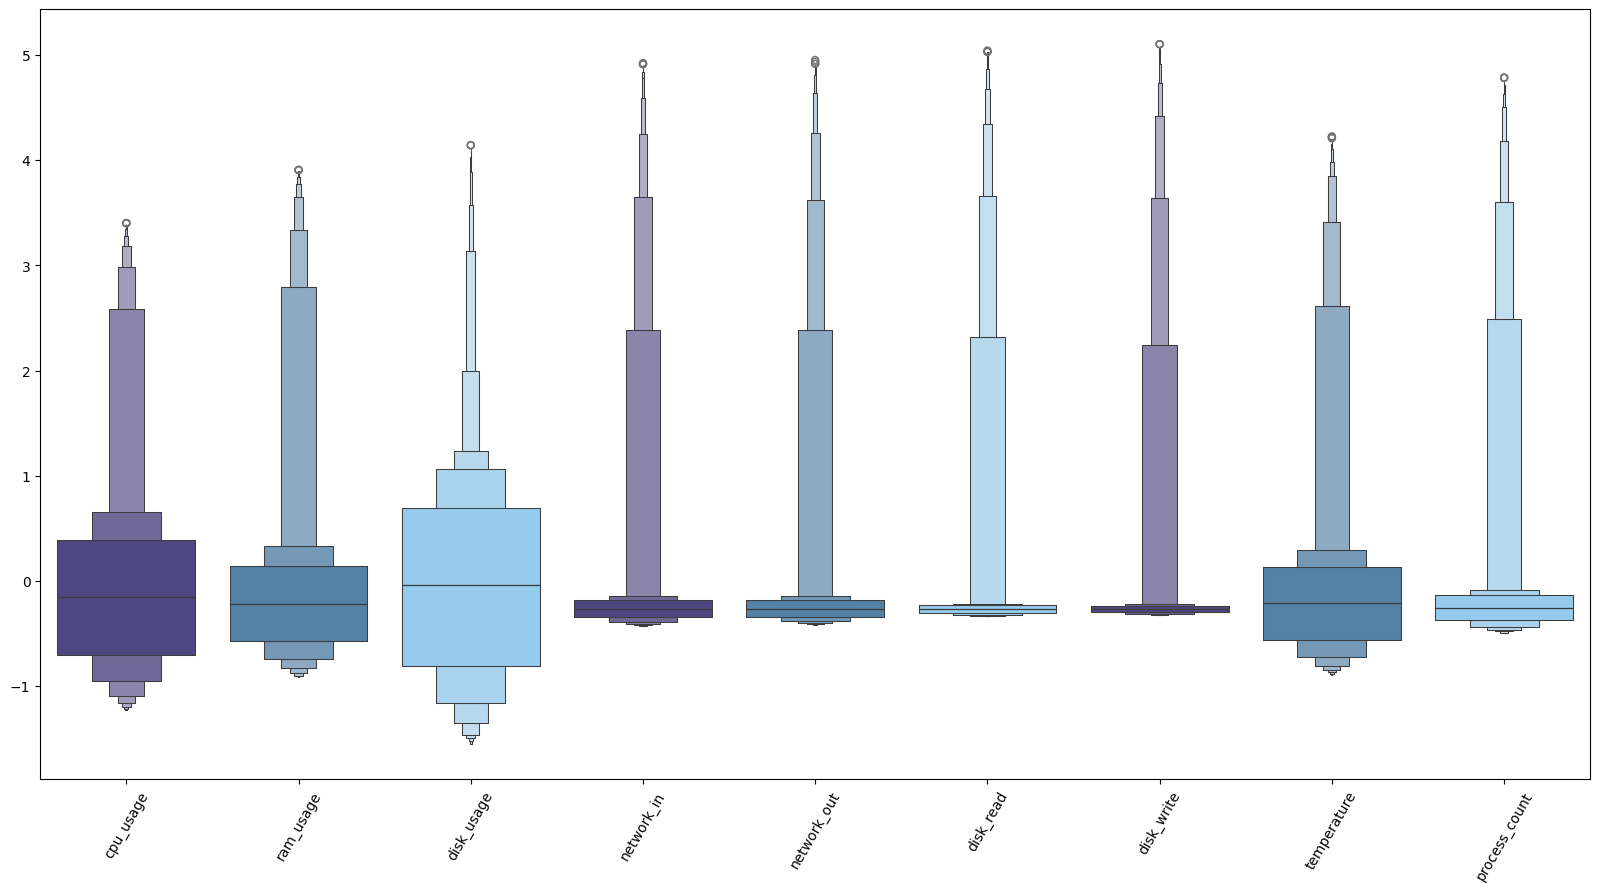

In [13]:
plt.figure(figsize=(20,10))
sns.boxenplot(data=X_scaled,palette=colors)
plt.xticks(rotation=60)
plt.show()

In [14]:
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.20, random_state=25)

In [15]:
pipeline_lr=Pipeline([('lr_classifier',LogisticRegression())])

pipeline_dt=Pipeline([('dt_classifier',DecisionTreeClassifier())])

pipeline_gbcl=Pipeline([('gbcl_classifier',GradientBoostingClassifier())])

pipeline_rf=Pipeline([('rf_classifier',RandomForestClassifier())])

pipeline_knn=Pipeline([('knn_classifier',KNeighborsClassifier())])



Pipelines=[pipeline_lr, pipeline_dt, pipeline_gbcl, pipeline_rf, pipeline_knn]

pipe_dict={0: 'Logistic Regression', 1: 'Decision Tree', 2: 'Gradient Boost', 3: 'Random Forest', 4: 'KNN'}

for pipe in Pipelines:
    pipe.fit(X_train, y_train)

In [16]:
cv_results_accuracy=[]
for i, model in enumerate(Pipelines):
    cv_score= cross_val_score(model, X_train ,y_train, cv=12)
    cv_results_accuracy.append(cv_score)
    print("%s: %f" % (pipe_dict[i],cv_score.mean()))

Logistic Regression: 1.000000
Decision Tree: 1.000000
Gradient Boost: 1.000000
Random Forest: 1.000000
KNN: 1.000000


In [17]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
import joblib

pipeline_isof = Pipeline([
    ('scaler', StandardScaler()),
    ('isof_classifier', IsolationForest(
        n_estimators=200,
        contamination=0.075,
        random_state=42
    ))
])


pipeline_isof.fit(X_train)
joblib.dump(pipeline_isof, "isolation_forest.joblib")

['isolation_forest.joblib']

In [18]:
y_train.sample(10)

9155    0
658     1
7594    1
5474    1
7081    0
5053    0
6145    0
7211    0
5139    0
6002    0
Name: anomaly, dtype: int64

In [19]:
df.iloc[5824]

cpu_usage          92.8
ram_usage          99.8
disk_usage         59.9
network_in        745.0
network_out      1340.0
disk_read         792.0
disk_write        531.0
temperature        91.1
process_count     570.0
anomaly             1.0
Name: 5824, dtype: float64

In [20]:
import pandas as pd
import joblib

model = joblib.load("isolation_forest.joblib")

features = {
    "cpu_usage": 92.8,
    "ram_usage": 99.8,
    "disk_usage": 59.9,
    "network_in": 745.0,
    "network_out": 1340.0,
    "disk_read": 792.0,
    "disk_write": 531.0,
    "temperature": 91.1,
    "process_count": 570.0
}

X_new = pd.DataFrame([features])

prediction = model.predict(X_new)

if prediction[0] == -1:
    result = 1
    message = "Anomalie détectée"
else:
    result = 0
    message = "Observation normale"


print("Anomaly detection :", result)
print(message)

Anomaly detection : 1
Anomalie détectée
